In [19]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import MultiLabelBinarizer
import matplotlib.pyplot as plt


In [11]:
df = pd.read_json("../data/supervise_myth_clusters.json", lines=True)
df_tropes = pd.read_json("../data/binary_myth_tropes.json", orient="records", lines=True)
print(df.columns)
print(X_diff.isna().sum().sort_values(ascending=False).head(10))

Index(['id', 'text', 'type', 'source', 'imdb_title', 'imdb_year',
       'imdb_genres', 'inferred_media_type', 'combined_text',
       'has_semantic_match', 'has_lexical_match',
       'has_sentence_myth_trope_hit', 'max_trope_similarity', 'myth_hit_count',
       'myth_theme', 'cluster', 'has_myth_hit', 'has_myth_trope_hit',
       'agglo_cluster'],
      dtype='object')
imdb_year                      995
type                             0
source                           0
inferred_media_type              0
has_semantic_match               0
has_lexical_match                0
has_sentence_myth_trope_hit      0
max_trope_similarity             0
myth_hit_count                   0
has_myth_hit                     0
dtype: int64


In [12]:
y = df['cluster']

df['imdb_genres_clean'] = df['imdb_genres'].apply(lambda x: x if isinstance(x, list) else [])

X_diff = df.drop(columns=['cluster', 'agglo_cluster', 'myth_theme', 'id', 'text', 'combined_text', 'imdb_title', 'imdb_genres', 'imdb_year'])


mlb = MultiLabelBinarizer()
genre_dummies = pd.DataFrame(mlb.fit_transform(df['imdb_genres_clean']), 
                             columns=[f'genre_{g}' for g in mlb.classes_],
                             index=df.index)

# Drop the combined genres string column if present
X_diff = X_diff.drop(columns=['imdb_genres_str', 'imdb_genres_clean'], errors='ignore').dropna(axis=1, how='all')

# Concatenate genre multi-hot columns to predictors
X_diff = pd.concat([X_diff, genre_dummies], axis=1)
X_diff.dtypes

type                            object
source                          object
inferred_media_type             object
has_semantic_match                bool
has_lexical_match                 bool
has_sentence_myth_trope_hit       bool
max_trope_similarity           float64
myth_hit_count                   int64
has_myth_hit                      bool
has_myth_trope_hit                bool
genre_action                     int64
genre_adventure                  int64
genre_animation                  int64
genre_biography                  int64
genre_comedy                     int64
genre_crime                      int64
genre_documentary                int64
genre_drama                      int64
genre_family                     int64
genre_fantasy                    int64
genre_film-noir                  int64
genre_game-show                  int64
genre_history                    int64
genre_horror                     int64
genre_music                      int64
genre_musical            

In [13]:
X_encoded = pd.get_dummies(X_diff, drop_first=True)

In [14]:
ovr_lr = OneVsRestClassifier(
    LogisticRegression(
        penalty='l2',
        solver='liblinear',  # works well for small to medium datasets
        max_iter=500,
        random_state=42
    )
)

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(ovr_lr, X_encoded, y, cv=cv, scoring='f1_macro')
print(f"Cross-validated Macro F1 Score: {np.mean(scores):.4f} ± {np.std(scores):.4f}")

Cross-validated Macro F1 Score: 0.5890 ± 0.0094


In [16]:
ovr_lr.fit(X_encoded, y)

,estimator,LogisticRegre...r='liblinear')
,n_jobs,None
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42


In [17]:
y_pred = ovr_lr.predict(X_encoded)
print(classification_report(y, y_pred))
print(confusion_matrix(y, y_pred))

              precision    recall  f1-score   support

           0       0.53      0.67      0.59       609
           1       1.00      0.98      0.99       794
           2       0.53      0.56      0.55       528
           3       0.53      0.26      0.35       344

    accuracy                           0.69      2275
   macro avg       0.65      0.62      0.62      2275
weighted avg       0.69      0.69      0.68      2275

[[408   0 156  45]
 [  7 776  10   1]
 [200   0 297  31]
 [162   0  94  88]]


In [18]:
feature_names = X_encoded.columns

for idx, estimator in enumerate(ovr_lr.estimators_):
    coefs = estimator.coef_.flatten()
    top_indices = np.argsort(np.abs(coefs))[::-1][:10]  # top absolute coefficients
    
    print(f"\nTop features for Cluster {idx}:")
    for i in top_indices:
        sign = '+' if coefs[i] >= 0 else '-'
        print(f"{feature_names[i]} ({sign}): {coefs[i]:.4f}")


Top features for Cluster 0:
inferred_media_type_unknown (-): -5.1648
inferred_media_type_skip (-): -2.3892
max_trope_similarity (+): 1.1328
source_High Fantasy Works (+): 0.9694
genre_crime (-): -0.9088
source_1990S British Scifi Tv (-): -0.7496
genre_talk-show (-): -0.7447
genre_action (-): -0.6677
genre_film-noir (+): 0.6548
source_Video Games Based On Mythology (+): 0.6333

Top features for Cluster 1:
inferred_media_type_unknown (+): 7.4703
inferred_media_type_skip (+): 4.2947
inferred_media_type_both (-): -1.5490
inferred_media_type_screen (-): -1.2724
genre_musical (+): 1.0156
genre_animation (+): 0.9090
source_Fantasy Film Category (+): 0.8451
genre_mystery (-): -0.7944
genre_talk-show (+): 0.7544
genre_sci-fi (+): 0.7379

Top features for Cluster 2:
inferred_media_type_unknown (-): -4.0904
max_trope_similarity (-): -2.0256
inferred_media_type_skip (-): -1.6445
genre_history (-): -1.2975
genre_romance (+): 1.0119
myth_hit_count (-): -1.0025
source_Fantasy Film Category (-): -0.9

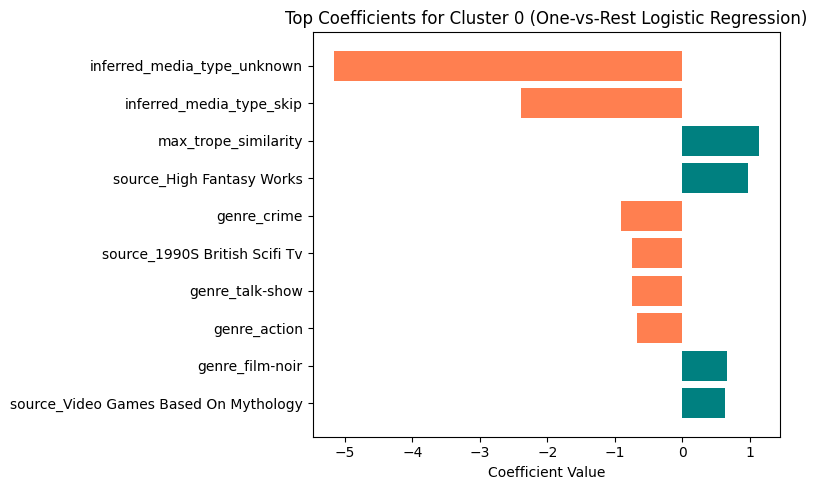

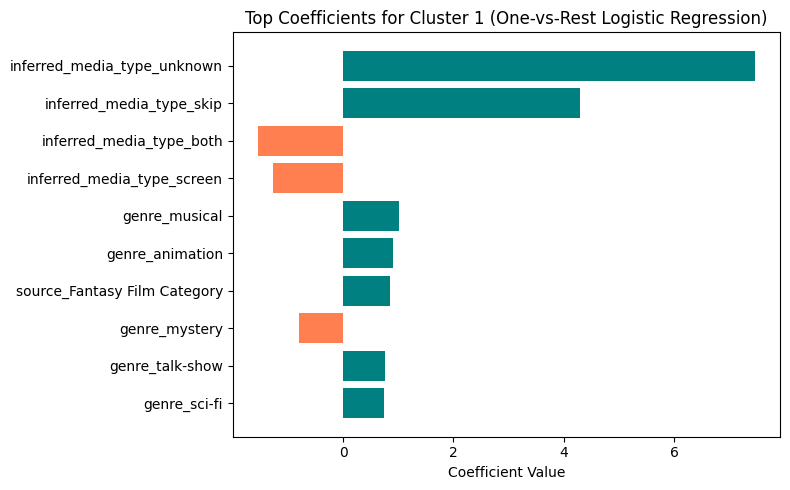

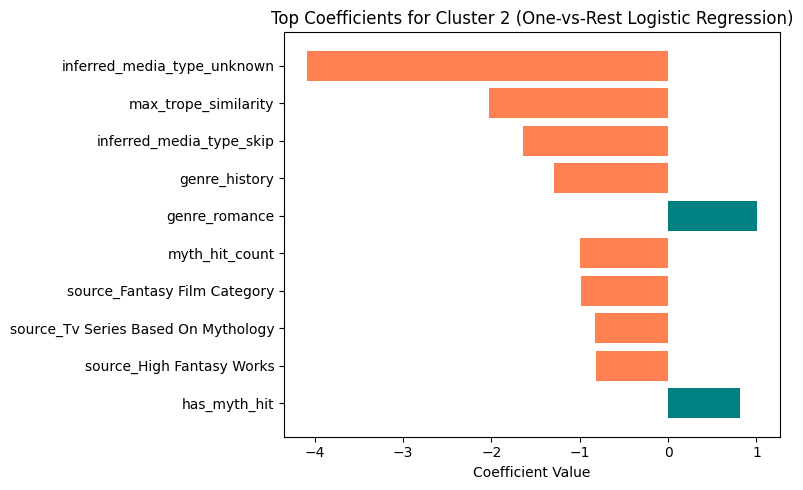

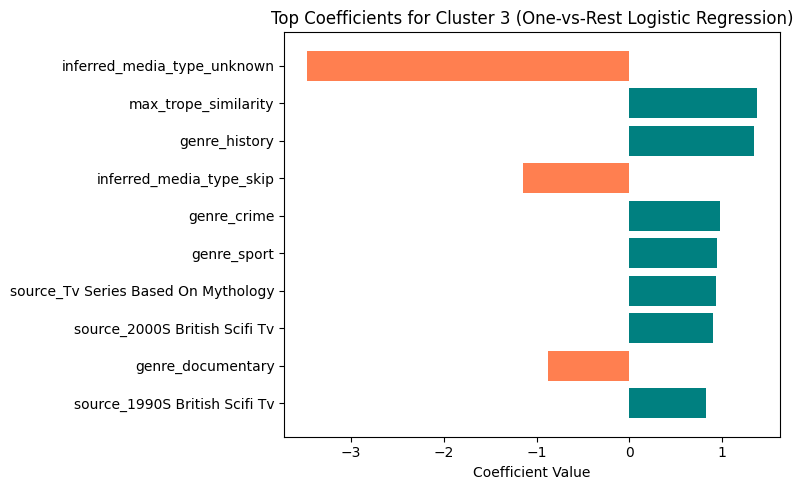

In [20]:
feature_names = X_encoded.columns

for idx, estimator in enumerate(ovr_lr.estimators_):
    coefs = estimator.coef_.flatten()
    # Get indices of top 10 coefficients by absolute value
    top_indices = np.argsort(np.abs(coefs))[::-1][:10]
    
    top_features = [feature_names[i] for i in top_indices]
    top_coefs = coefs[top_indices]
    
    # Create color map: teal for positive, coral for negative
    colors = ['teal' if val >= 0 else 'coral' for val in top_coefs]
    
    plt.figure(figsize=(8, 5))
    plt.barh(top_features[::-1], top_coefs[::-1], color=colors[::-1])
    plt.xlabel("Coefficient Value")
    plt.title(f"Top Coefficients for Cluster {idx} (One-vs-Rest Logistic Regression)")
    plt.tight_layout()
    plt.show()